In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [3]:
from sklearn.linear_model import Perceptron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

In [4]:
df=pd.read_csv('train.csv')

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.shape

(9170, 785)

In [7]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [8]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,1
pixel780,1
pixel781,1
pixel782,1


In [9]:
#preprocessing
X=df.drop(['label'],axis=1)
y=df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=42)

In [11]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [12]:
import numpy as np
#reshaping data
X_train_img=X_train.values.reshape(-1,28,28)
X_test_img=X_test.values.reshape(-1,28,28)

# Replace NaN values with 0 to prevent 'loss: nan' during training
X_train_img = np.nan_to_num(X_train_img, nan=0.0)
X_test_img = np.nan_to_num(X_test_img, nan=0.0)

In [13]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [14]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [15]:
Perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [16]:
Perceptron.compile(optimizer=SGD(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [36]:
history_percp=Perceptron.fit(X_train_img,
                       y_train_cat,
                       epochs=10,
                       batch_size=32,
                       validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7674 - loss: 1.1927 - val_accuracy: 0.7463 - val_loss: 1.2047
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7778 - loss: 1.1447 - val_accuracy: 0.7539 - val_loss: 1.1600
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7859 - loss: 1.1019 - val_accuracy: 0.7631 - val_loss: 1.1202
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7921 - loss: 1.0634 - val_accuracy: 0.7678 - val_loss: 1.0842
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7988 - loss: 1.0287 - val_accuracy: 0.7747 - val_loss: 1.0517
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8042 - loss: 0.9973 - val_accuracy: 0.7816 - val_loss: 1.0222
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8073 - loss: 0.9686 - val_accuracy: 0.7863 - val_loss: 0.9952
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8100 - loss: 0.9425 - val_accuracy: 0.

In [18]:
acc_perceptron=Perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [19]:
acc_perceptron

0.7400066256523132

In [20]:
#ANN
ANN=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [21]:
ANN.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [38]:
history_ann=ANN.fit(X_train_img,
                y_train_cat,
                epochs=10,
                batch_size=32,
                validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9987 - loss: 0.0112 - val_accuracy: 0.9386 - val_loss: 0.2389
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9992 - loss: 0.0080 - val_accuracy: 0.9465 - val_loss: 0.2228
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9998 - loss: 0.0045 - val_accuracy: 0.9419 - val_loss: 0.2316
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9993 - loss: 0.0048 - val_accuracy: 0.9389 - val_loss: 0.2512
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9956 - loss: 0.0155 - val_accuracy: 0.9336 - val_loss: 0.2999
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9961 - loss: 0.0143 - val_accuracy: 0.9445 - val_loss: 0.2530
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9917 - loss: 0.0245 - val_accuracy: 0.9392 - val_loss: 0.2642
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9967 - loss: 0.0110 - val_accuracy: 0.

In [23]:
acc_ann=ANN.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [24]:
acc_ann

0.9421870112419128

In [25]:
#reshaping for cnn
X_train_cnn=X_train_img.reshape(-1,28,28,1)
X_test_cnn=X_test_img.reshape(-1,28,28,1)

In [26]:
cnn=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [27]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [39]:
history_cnn=cnn.fit(X_train_cnn,
                y_train_cat,
                epochs=5,
                batch_size=32,
                validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9715 - loss: 0.0919 - val_accuracy: 0.9779 - val_loss: 0.0724
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9785 - loss: 0.0702 - val_accuracy: 0.9742 - val_loss: 0.0790
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9801 - loss: 0.0632 - val_accuracy: 0.9749 - val_loss: 0.0793
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9795 - loss: 0.0606 - val_accuracy: 0.9752 - val_loss: 0.0752
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9858 - loss: 0.0512 - val_accuracy: 0.9762 - val_loss: 0.0763


In [29]:
cnn_acc=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [30]:
cnn_acc

0.9712586998939514

In [31]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

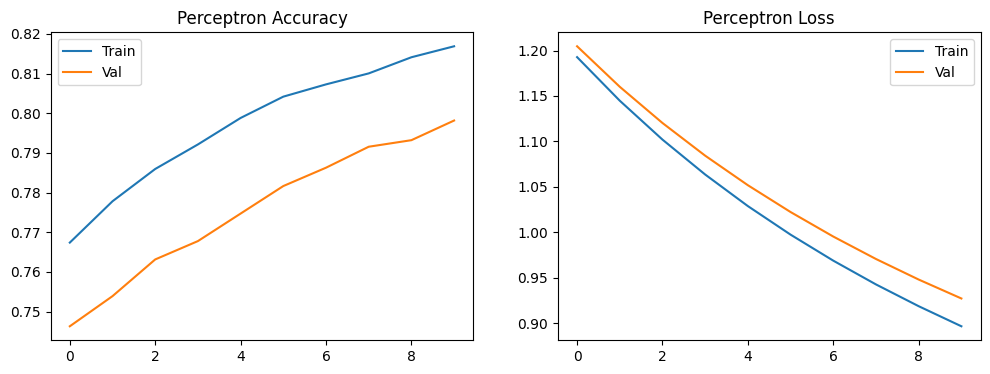

In [37]:
plot_training(history_percp, "Perceptron")

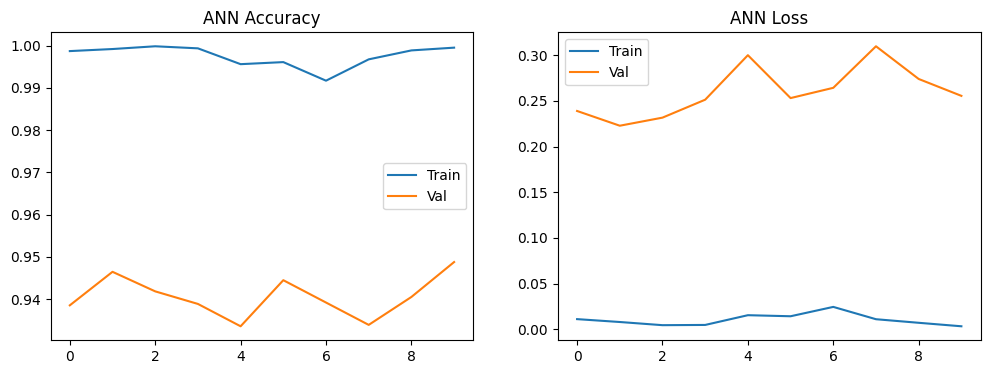

In [41]:
plot_training(history_ann, "ANN")

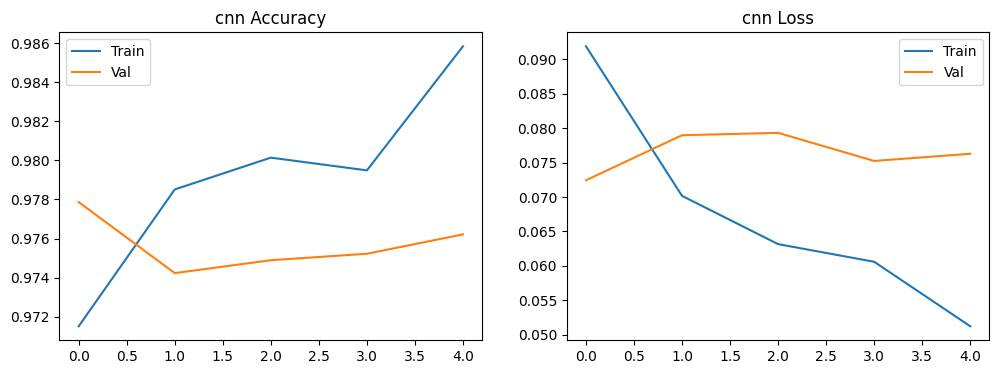

In [40]:
plot_training(history_cnn, "cnn")

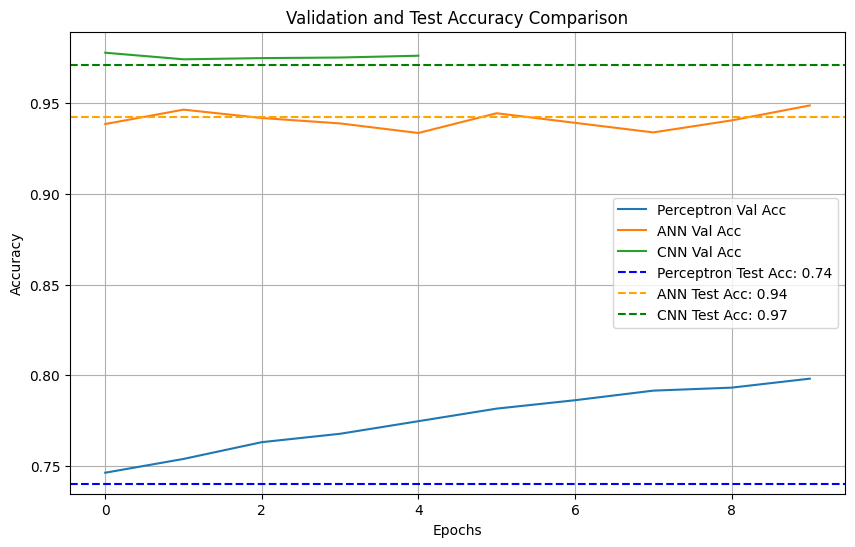

In [46]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron Val Acc")
plt.plot(history_ann.history['val_accuracy'], label="ANN Val Acc")
plt.plot(history_cnn.history['val_accuracy'], label="CNN Val Acc")

# Add horizontal lines for final test accuracies
plt.axhline(y=acc_perceptron, color='blue', linestyle='--', label=f'Perceptron Test Acc: {acc_perceptron:.2f}')
plt.axhline(y=acc_ann, color='orange', linestyle='--', label=f'ANN Test Acc: {acc_ann:.2f}')
plt.axhline(y=cnn_acc, color='green', linestyle='--', label=f'CNN Test Acc: {cnn_acc:.2f}')

plt.title("Validation and Test Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true.iloc[idx]}") # Changed to .iloc[idx]
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


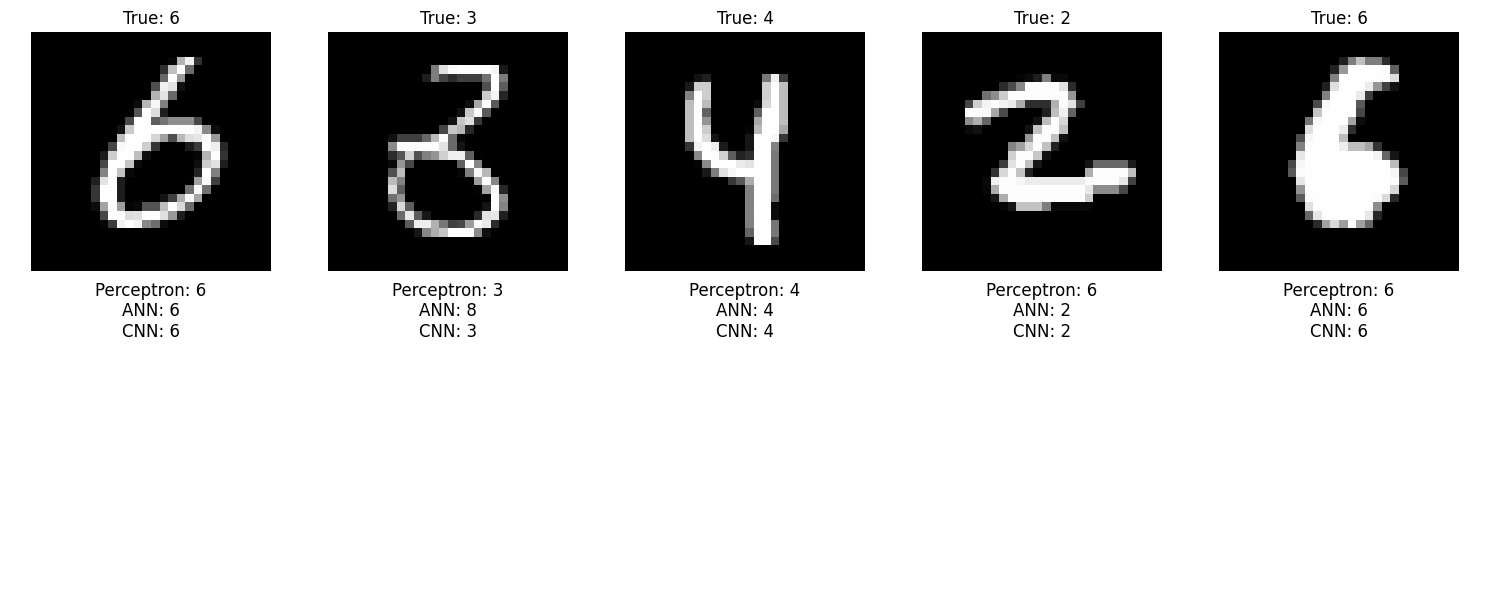

In [58]:
show_side_by_side([Perceptron, ANN, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


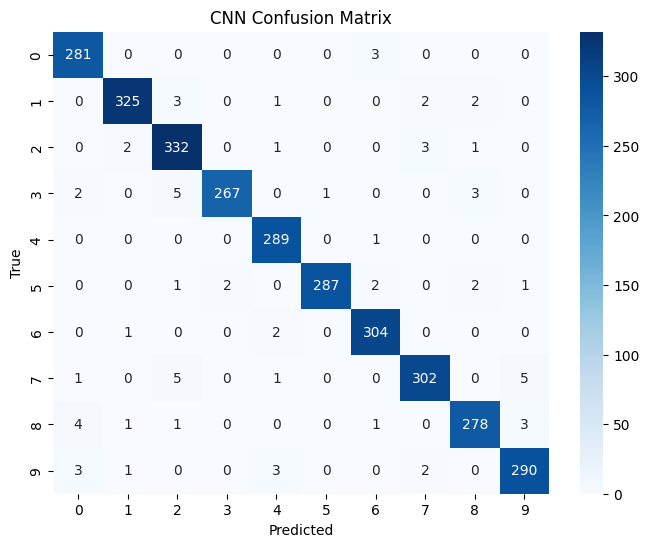

In [59]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


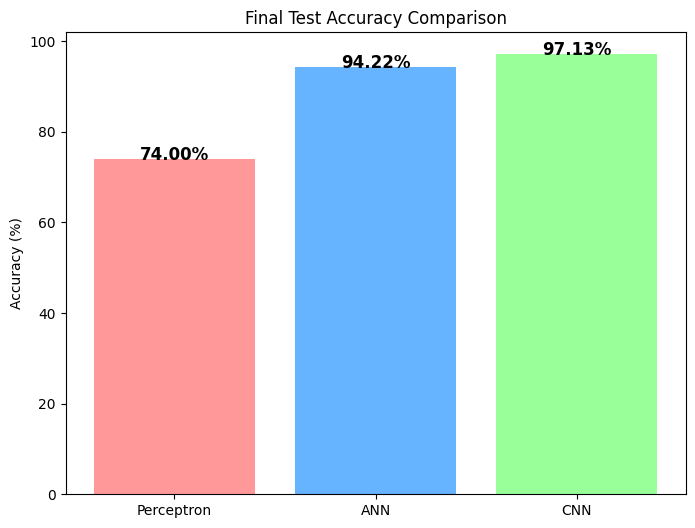

In [63]:
final_accs = [acc_perceptron*100, acc_ann*100, cnn_acc*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
# plt.ylim(80, 100) # Removed this line to show all bars
plt.show()

In [64]:
from tensorflow.keras.models import save_model

save_model(Perceptron, 'perceptron_model.h5')
print("Perceptron model saved successfully as 'perceptron_model.h5'")

Perceptron model saved successfully as 'perceptron_model.h5'


In [65]:
save_model(ANN, 'ann_model.h5')
print("ANN model saved successfully as 'ann_model.h5'")

ANN model saved successfully as 'ann_model.h5'


In [66]:
from tensorflow.keras.models import save_model

save_model(cnn, 'cnn_model.keras')
print("CNN model saved successfully as 'cnn_model.keras'")

CNN model saved successfully as 'cnn_model.keras'
